5. Is there any relationship between lateness (ADHERENCE) and headway deviation? The headway deviation variable is contained in the HDWY_DEV column. See the notes under number 9 for a description of headway and headway deviation.

In [15]:
import pandas as pd
import matplotlib.pyplot as plt

In [16]:
wego = pd.read_csv("../data/Headway Data, 8-1-2023 to 9-30-2023.csv")

In [31]:
#headway percentage allows standardized comparison of deviation
wego['HDWY_PCT'] = round(wego['HDWY_DEV'] / wego['SCHEDULED_HDWY'] * 100,2)

In [18]:
#to avoid 'inf' divide by zero errors
wego = wego[wego.SCHEDULED_HDWY != 0]

In [19]:
q5 = wego[['ADHERENCE','HDWY_PCT']]

In [32]:
#dropping null adherence and headway which can't otherwise be calculated from dataset
q5 = q5.dropna()

In [21]:
q5.describe()

,ADHERENCE,HDWY_PCT
count,265847.000000,265847.000000
mean,-3.503547,3.162494
std,6.501571,46.666776
min,-948.533333,-100.000000
25%,-4.616666,-14.170000
50%,-2.216666,0.180000
75%,-0.666666,15.500000
max,85.666666,2417.500000


In [22]:
q5.corr()

,ADHERENCE,HDWY_PCT
ADHERENCE,1.000000,-0.203726
HDWY_PCT,-0.203726,1.000000


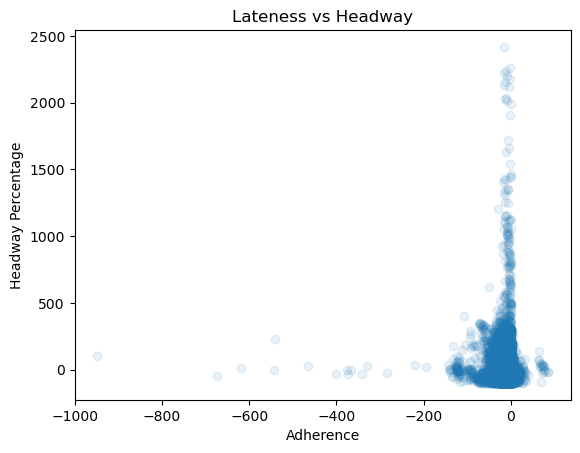

In [23]:
plt.scatter(q5.ADHERENCE, q5.HDWY_PCT, alpha=0.1, marker='o')

plt.xlabel("Adherence")
plt.ylabel("Headway Percentage")
plt.title("Lateness vs Headway")

plt.savefig('../visualizations/AdherenceHeadwayScatter.png', bbox_inches='tight', pad_inches=0.1)
plt.show()


In [28]:
#adherence IQR
a_q3 = q5.ADHERENCE.quantile(0.75)
a_q1 = q5.ADHERENCE.quantile(0.25)
a_IQR = a_q3 - a_q1

In [29]:
#upper and lower bounds of adherence outliers
a_upper = a_q3 + 1.5 * a_IQR
a_lower = a_q1 - 1.5 * a_IQR

In [30]:
#headway percentage IQR
h_q3 = q5.HDWY_PCT.quantile(0.75)
h_q1 = q5.HDWY_PCT.quantile(0.25)
h_IQR = h_q3 - h_q1

#upper and lower bounds of headway percentage outliers
h_upper = h_q3 + 1.5 * h_IQR
h_lower = h_q1 - 1.5 * h_IQR

In [27]:
q5_outliers_removed = q5[(q5.ADHERENCE <= a_upper) & (q5.ADHERENCE >= a_lower) & (q5.HDWY_PCT <= h_upper) & (q5.HDWY_PCT >= h_lower)]

In [16]:
q5_outliers_removed.corr()

,ADHERENCE,HDWY_PCT
ADHERENCE,1.000000,-0.512748
HDWY_PCT,-0.512748,1.000000


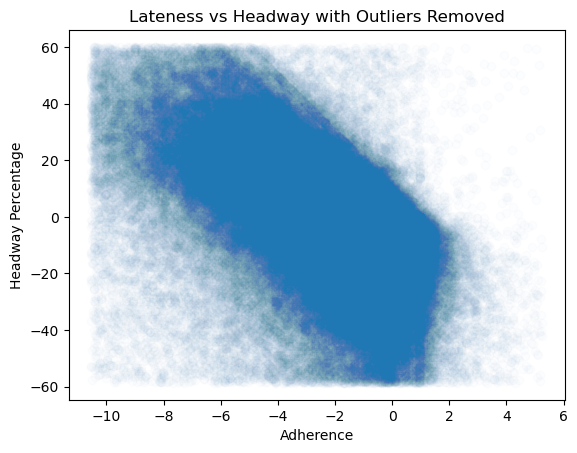

In [17]:
plt.scatter(q5_outliers_removed.ADHERENCE, q5_outliers_removed.HDWY_PCT, alpha=0.01, marker='o')

plt.xlabel("Adherence")
plt.ylabel("Headway Percentage")
plt.title("Lateness vs Headway with Outliers Removed")

plt.savefig('../visualizations/AdherenceHeadwaySansOutliers.png', bbox_inches='tight', pad_inches=0.1)
plt.show()
